# Phase 3-2 v2 — 종목별 LSTM 모델 심층 진단 (`05a_v2_lstm.ipynb`)

> **목적**: 02a Stockwise LSTM ensemble 의 **변동성 예측 자체** 를 다차원 진단.
>          백테스트/포트폴리오 평가는 별도 (`05a_v2.ipynb` §3-§5, `05a_v2_weighting.ipynb`).

## 12 심층 분석 항목

| § | 분석 | 산출 |
|---|---|---|
| §2-A | 월별 RMSE 시계열 | 전체 + LSTM/HAR/Ensemble line chart |
| §2-B | 종목 × 시기 RMSE Heatmap | 5 시기 × top/bottom 50 종목 |
| §2-C | 종목별 Forecast Bias | over-/underestimation 분포 |
| §2-D | 변동성 Regime별 예측력 | 종목 vol quintile별 RMSE |
| §2-E | VIX 분위별 예측 정확도 | low/mid/high VIX × LSTM vs HAR |
| §2-F | Diebold-Mariano test | 종목별 LSTM vs HAR 통계적 유의성 |
| §2-G | Sector × Best Model 교차표 | sector × {LSTM/HAR/Ensemble} 분포 |
| §2-H | 종목별 가중치 안정성 | w_v4 rolling std |
| §2-I | 시기별 예측 vs 실제 산점도 | 5 시기 subplot grid |
| §2-J | Top/Bottom 10 종목 case study | RMSE 최우/최열 timeline |
| §2-K | CV fold별 성능 | fold k=0~223 RMSE 추이 |
| §2-L | y_true vs y_pred 분포 비교 | KDE, QQ plot, percentile |

## 사전 조건
- ✅ `data/ensemble_predictions_stockwise.csv` (02a 결과)
- ✅ `data/daily_panel.csv` (vol_21d)
- ✅ `data/vix_daily.csv`
- 🔵 (선택) `data/ticker_sector_mapping.csv` — §2-G sector 분석. 없으면 fallback

**가중치 무관**: 본 노트북은 단일 LSTM ensemble 모델을 진단. mcap/eq/rp 시나리오와 무관.

## §1. 환경 부트스트랩 + 데이터 로드

In [31]:
%load_ext autoreload
%autoreload 2

import sys, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '05a_v2_lstm_diag'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05a_v2_lstm_diag


In [32]:
# 데이터 로드
ens_sw = pd.read_csv(
    DATA_DIR / 'ensemble_predictions_stockwise.csv',
    parse_dates=['date'],
)
print(f'ensemble_sw: {ens_sw.shape}')
print(f'  unique tickers: {ens_sw["ticker"].nunique()}')
print(f'  unique folds: {ens_sw["fold"].nunique()} (0 ~ {ens_sw["fold"].max()})')
print(f'  date range: {ens_sw["date"].min().date()} ~ {ens_sw["date"].max().date()}')

# inf 제거 (stale 7종목 y_true 113행)
n_before = len(ens_sw)
inf_mask = np.isfinite(ens_sw['y_true'])
ens_sw = ens_sw[inf_mask].copy()
print(f'  inf 제거: {n_before - len(ens_sw)} 행 ({(1 - len(ens_sw)/n_before)*100:.4f}%)')

# year-month + period_label 추가
ens_sw['ym'] = ens_sw['date'].dt.to_period('M')
ens_sw['year'] = ens_sw['date'].dt.year

# 5 시기 분류 (02a/05a §5 와 일관)
def assign_period(d):
    if d < pd.Timestamp('2015-01-01'): return 'P1 (2010-2014)'
    elif d < pd.Timestamp('2019-01-01'): return 'P2 (2015-2018)'
    elif d < pd.Timestamp('2021-01-01'): return 'P3 (2019-2020)'
    elif d < pd.Timestamp('2023-01-01'): return 'P4 (2021-2022)'
    else: return 'P5 (2023-2025)'
ens_sw['period'] = ens_sw['date'].apply(assign_period)
PERIOD_ORDER = ['P1 (2010-2014)', 'P2 (2015-2018)', 'P3 (2019-2020)',
                'P4 (2021-2022)', 'P5 (2023-2025)']

# loss diff 컬럼 (DM-test 등 활용)
ens_sw['err_lstm'] = ens_sw['y_pred_lstm'] - ens_sw['y_true']
ens_sw['err_har'] = ens_sw['y_pred_har'] - ens_sw['y_true']
ens_sw['err_ens'] = ens_sw['y_pred_ensemble'] - ens_sw['y_true']
ens_sw['sq_lstm'] = ens_sw['err_lstm'] ** 2
ens_sw['sq_har'] = ens_sw['err_har'] ** 2
ens_sw['sq_ens'] = ens_sw['err_ens'] ** 2

# panel: vol_21d (가벼운 컬럼만)
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'vol_21d'],
)
print(f'panel (vol_21d): {panel.shape}')

# vix_daily
vix = pd.read_csv(DATA_DIR / 'vix_daily.csv', parse_dates=['date'])
vix = vix.set_index('date')['VIX']
print(f'vix: {len(vix)} days, range {vix.index.min().date()} ~ {vix.index.max().date()}')

# sector 매핑 (선택적, fallback 처리)
sector_map_path = DATA_DIR / 'ticker_sector_mapping.csv'
if sector_map_path.exists():
    sector_map = pd.read_csv(sector_map_path).set_index('ticker')['sector']
    print(f'✅ sector mapping 로드: {len(sector_map)} 종목')
    SECTOR_AVAILABLE = True
else:
    sector_map = pd.Series(dtype='object')
    print('⚠️ ticker_sector_mapping.csv 부재 → §2-G 부분 결과 출력')
    print('  (선택) yfinance 로 sector 받으려면:')
    print('    python scripts/_build_ticker_sector_mapping.py')
    SECTOR_AVAILABLE = False

ensemble_sw: (2468883, 9)
  unique tickers: 613
  unique folds: 224 (0 ~ 223)
  date range: 2007-04-23 ~ 2025-12-01
  inf 제거: 113 행 (0.0046%)
panel (vol_21d): (3395442, 3)
vix: 4358 days, range 2009-01-02 ~ 2026-04-30
✅ sector mapping 로드: 613 종목


## §2. 종목별 LSTM 모델 심층 진단 — 12 분석

### §2-A. 월별 RMSE 시계열 (LSTM vs HAR vs Ensemble)

월 단위로 전체 종목 평균 RMSE 추이. 시기별 모델 강약, 위기 (COVID/긴축) 영향 시각화.

  §2-A. 월별 RMSE 시계열 (LSTM vs HAR vs Ensemble)
  월별 RMSE 통계 (2010-2025, n=192 개월):
    rmse_lstm: mean=0.4069, std=0.1395, min=0.2470, max=1.5267
    rmse_har: mean=0.3763, std=0.1123, min=0.2493, max=1.3220
    rmse_ens: mean=0.3696, std=0.0985, min=0.2396, max=1.2819


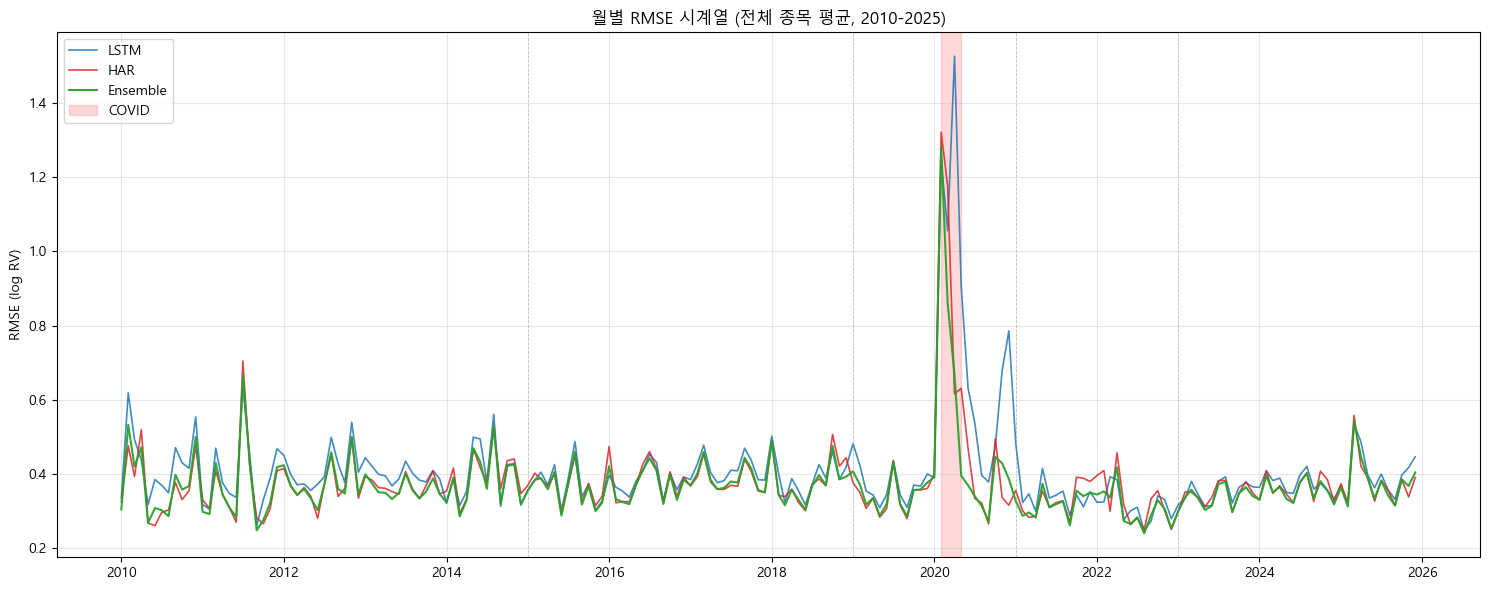

  💾 A_monthly_rmse_timeline.png
  💾 A_monthly_rmse.csv


In [33]:
# §2-A. 월별 RMSE 시계열
print('=' * 75)
print('  §2-A. 월별 RMSE 시계열 (LSTM vs HAR vs Ensemble)')
print('=' * 75)

monthly_rmse = ens_sw.groupby('ym').agg(
    rmse_lstm=('sq_lstm', lambda x: np.sqrt(x.mean())),
    rmse_har=('sq_har', lambda x: np.sqrt(x.mean())),
    rmse_ens=('sq_ens', lambda x: np.sqrt(x.mean())),
    n=('y_true', 'count'),
).reset_index()
monthly_rmse['date'] = monthly_rmse['ym'].dt.to_timestamp()

# OOS 기간 (2010-2025) 만 시각화
mr = monthly_rmse[monthly_rmse['date'] >= '2010-01-01'].copy()

print(f'  월별 RMSE 통계 (2010-2025, n={len(mr)} 개월):')
for col in ['rmse_lstm', 'rmse_har', 'rmse_ens']:
    s = mr[col]
    print(f'    {col}: mean={s.mean():.4f}, std={s.std():.4f}, min={s.min():.4f}, max={s.max():.4f}')

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(15, 6))
ax.plot(mr['date'], mr['rmse_lstm'], label='LSTM', color='#1f77b4', linewidth=1.2, alpha=0.85)
ax.plot(mr['date'], mr['rmse_har'], label='HAR', color='#d62728', linewidth=1.2, alpha=0.85)
ax.plot(mr['date'], mr['rmse_ens'], label='Ensemble', color='#2ca02c', linewidth=1.5, alpha=0.95)

# 시기 구분선
for ds in ['2015-01-01', '2019-01-01', '2021-01-01', '2023-01-01']:
    ax.axvline(pd.Timestamp(ds), color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
# COVID 음영
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-30'),
           alpha=0.15, color='red', label='COVID')

ax.set_title('월별 RMSE 시계열 (전체 종목 평균, 2010-2025)')
ax.set_ylabel('RMSE (log RV)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = OUT_DIR / 'A_monthly_rmse_timeline.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

# 결과 저장
monthly_rmse.to_csv(OUT_DIR / 'A_monthly_rmse.csv', index=False)
print(f'  💾 A_monthly_rmse.csv')

### §2-B. 종목 × 시기 RMSE Heatmap (5 시기 cover 종목만)

종목별 5 시기 RMSE 매트릭스. 어느 종목이 어느 시기에 약했는지 시각화.

⭐ **공정성 보강**: 5 시기 모두 cover 한 종목만 비교 (n_period == 5).
인수/파산/신규 종목의 단편 기간 RMSE 가 평균에 왜곡 영향 주는 것을 방지.

  §2-B. 종목 × 시기 RMSE Heatmap (5 시기 cover 종목만)
  전체 종목: 613
    5 시기 모두 cover: 503 (전 기간 학습)
    부분 cover:       110 (인수/파산/신규)

  Top 30 (어려운 — 5 시기 cover 중 RMSE 큰):
period  P1 (2010-2014)  P2 (2015-2018)  P3 (2019-2020)  P4 (2021-2022)  P5 (2023-2025)
ticker                                                                                
CVG           0.786000        0.645000        0.541000        0.589000        0.554000
PBI           0.471000        0.492000        0.786000        0.431000        0.368000
GME           0.342000        0.369000        0.724000        0.513000        0.550000
FOSL          0.477000        0.600000        0.521000        0.452000        0.384000
FHN           0.304000        0.298000        0.573000        0.668000        0.559000
DXC           0.492000        0.470000        0.704000        0.318000        0.404000
SMCI          0.361000        0.506000        0.569000        0.410000        0.518000
PCG           0.306000        0.553000        0.794

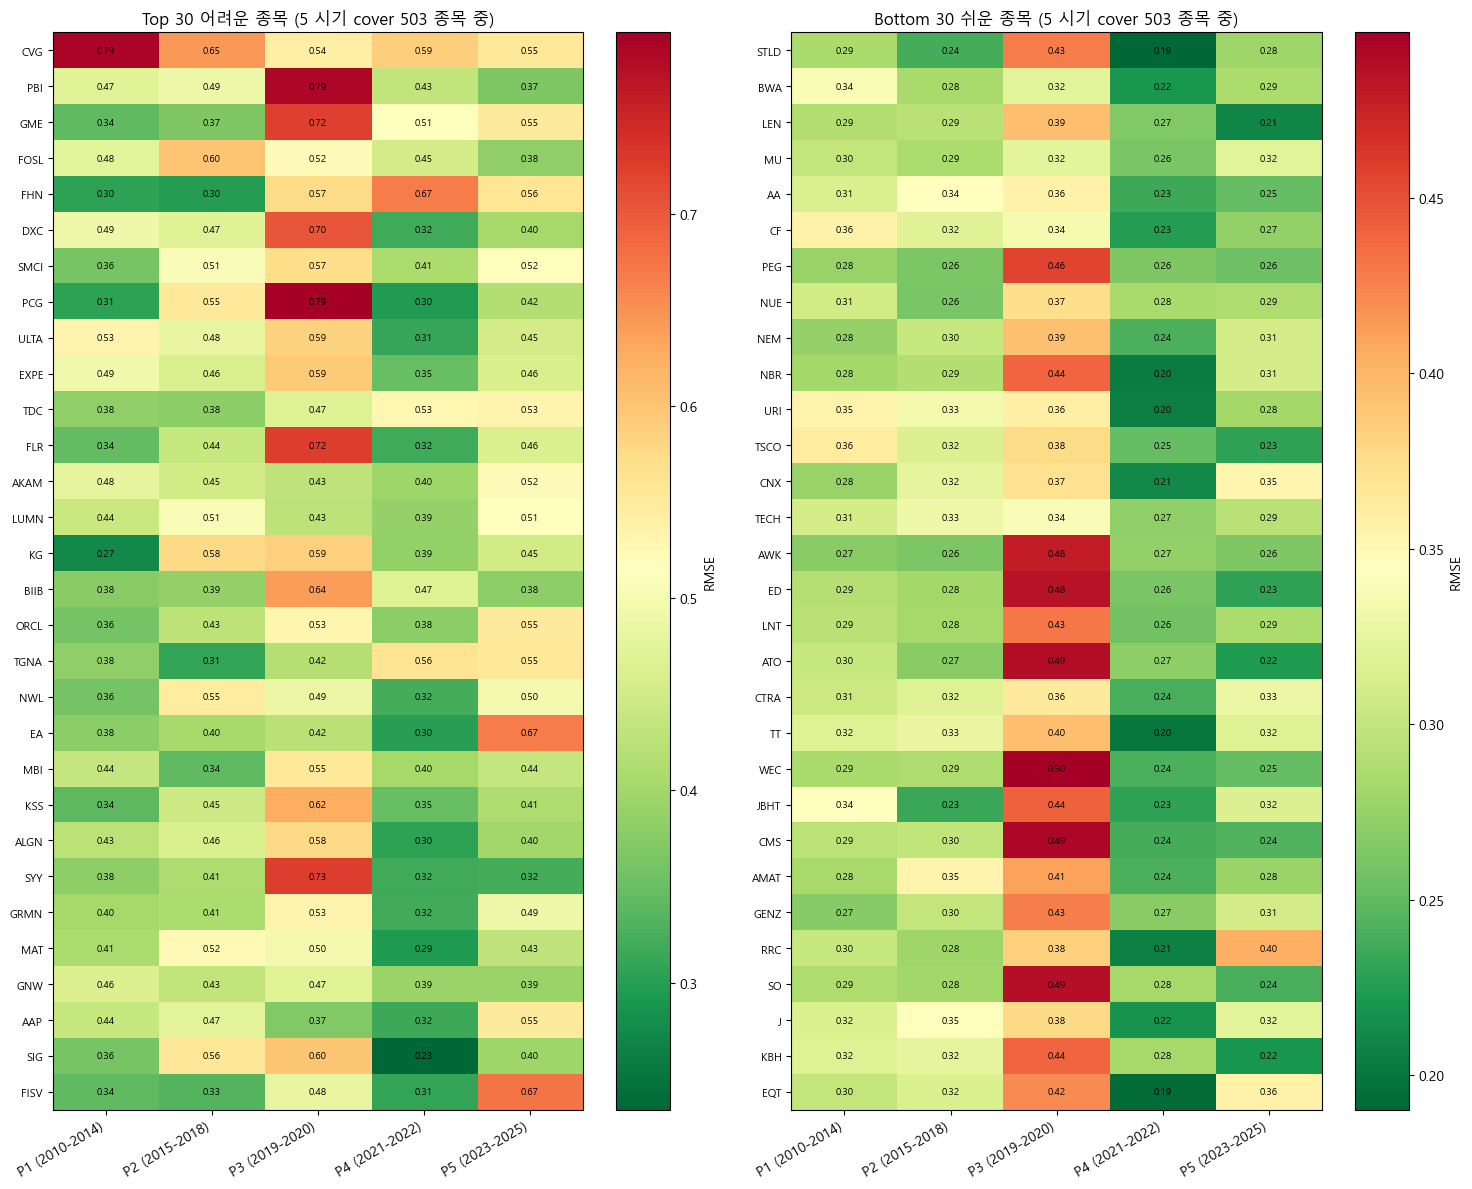

  💾 B_stock_period_rmse_heatmap.png
  💾 B_stock_period_rmse_all.csv (전체 613 종목, n_period 포함)
  💾 B_stock_period_rmse_full_only.csv (5 시기 cover 503 종목)


In [34]:
# §2-B. 종목 × 시기 RMSE Heatmap
print('=' * 75)
print('  §2-B. 종목 × 시기 RMSE Heatmap (5 시기 cover 종목만)')
print('=' * 75)

# OOS 2010-2025 만
ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01']

stock_period_rmse_full = ens_oos.groupby(['ticker', 'period'])['sq_ens'].apply(
    lambda x: np.sqrt(x.mean())
).unstack('period').reindex(columns=PERIOD_ORDER)

# n_period 컬럼 (5 시기 모두 cover 종목 식별)
stock_period_rmse_full['n_period'] = stock_period_rmse_full[PERIOD_ORDER].notna().sum(axis=1)
n_full = (stock_period_rmse_full['n_period'] == 5).sum()
n_part = (stock_period_rmse_full['n_period'] < 5).sum()
print(f'  전체 종목: {len(stock_period_rmse_full)}')
print(f'    5 시기 모두 cover: {n_full} (전 기간 학습)')
print(f'    부분 cover:       {n_part} (인수/파산/신규)')

# ⭐ 5 시기 모두 cover 한 종목만 비교 (공정성)
stock_period_rmse = stock_period_rmse_full[stock_period_rmse_full['n_period'] == 5].drop(columns='n_period')
stock_period_rmse['mean_rmse'] = stock_period_rmse.mean(axis=1)

top30 = stock_period_rmse.nlargest(30, 'mean_rmse').drop(columns='mean_rmse')
bot30 = stock_period_rmse.nsmallest(30, 'mean_rmse').drop(columns='mean_rmse')

print()
print(f'  Top 30 (어려운 — 5 시기 cover 중 RMSE 큰):')
print(top30.head(10).round(3).to_string())
print()
print(f'  Bottom 30 (쉬운 — 5 시기 cover 중 RMSE 작은):')
print(bot30.head(10).round(3).to_string())

# 시각화 (top + bottom 각각 heatmap)
fig, axes = plt.subplots(1, 2, figsize=(15, 12))

for ax, df, title in [(axes[0], top30, f'Top 30 어려운 종목 (5 시기 cover {n_full} 종목 중)'),
                       (axes[1], bot30, f'Bottom 30 쉬운 종목 (5 시기 cover {n_full} 종목 중)')]:
    im = ax.imshow(df.values, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index, fontsize=8)
    ax.set_title(title)
    # 값 표시
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            v = df.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='black', fontsize=7)
    plt.colorbar(im, ax=ax, label='RMSE')

plt.tight_layout()
out_path = OUT_DIR / 'B_stock_period_rmse_heatmap.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

# 전체 (single + full) 둘 다 저장 → 분석 가능
stock_period_rmse_full.to_csv(OUT_DIR / 'B_stock_period_rmse_all.csv')
stock_period_rmse.to_csv(OUT_DIR / 'B_stock_period_rmse_full_only.csv')
print(f'  💾 B_stock_period_rmse_all.csv (전체 {len(stock_period_rmse_full)} 종목, n_period 포함)')
print(f'  💾 B_stock_period_rmse_full_only.csv (5 시기 cover {n_full} 종목)')

### §2-C. 종목별 Forecast Bias (over- / underestimation)

`bias = mean(y_pred_ensemble - y_true)` 종목별. 양수: 변동성 과대예측, 음수: 과소예측.
모델이 systematic 한 편향을 가지는지 검정.

  §2-C. 종목별 Forecast Bias
  전체 종목: 613
  bias 통계 (Ensemble):
    mean: +0.0346
    median: +0.0418
    std: 0.0859
    overestimate (>0): 509 종목
    underestimate (<0): 104 종목

  Top 10 overestimation (모델이 변동성 큼으로 예측):
ticker  bias_ens  bias_lstm  bias_har
   NSM  0.672179   0.812725  0.575691
   ADT  0.322043   0.361223  0.289672
  TMUS  0.180181   0.224575  0.142936
  MOLX  0.172386   0.221365  0.132404
  OTIS  0.166531   0.143905  0.191715
   KHC  0.156799   0.219649  0.102264
    SE  0.155644   0.167506  0.149455
   AET  0.146817   0.196663  0.111413
  CRWD  0.145917   0.161866  0.132160
  CTVA  0.143959   0.170192  0.119115

  Top 10 underestimation (모델이 변동성 작음으로 예측):
ticker  bias_ens  bias_lstm  bias_har
   BMC -1.365299  -1.123935 -1.662582
   CBE -0.769815  -0.701816 -0.820159
  CPWR -0.264427  -0.162868 -0.362951
    TE -0.253691  -0.298707 -0.210460
   SLE -0.209599  -0.197010 -0.223182
  SEDG -0.161347  -0.167270 -0.167857
  DELL -0.157485  -0.156867 -0.161410
   VST -0.1479

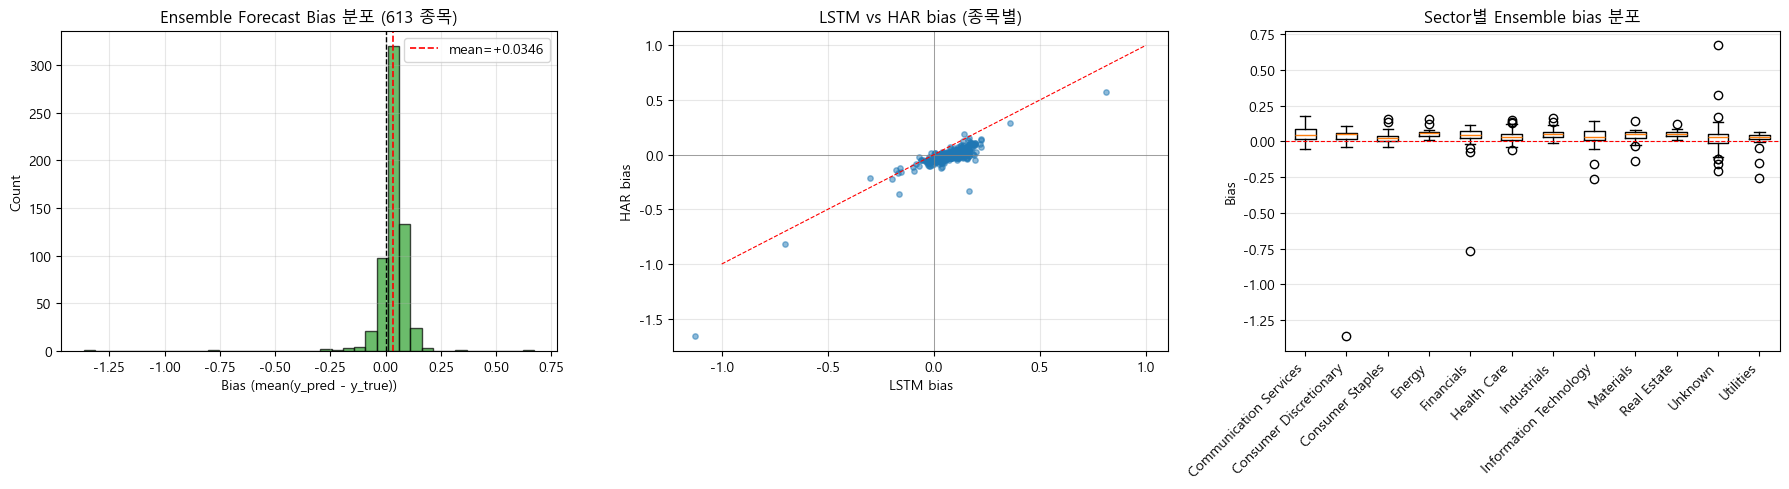

  💾 C_forecast_bias.png
  💾 C_forecast_bias.csv


In [35]:
# §2-C. 종목별 Forecast Bias
print('=' * 75)
print('  §2-C. 종목별 Forecast Bias')
print('=' * 75)

ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01']
bias_per_ticker = ens_oos.groupby('ticker').agg(
    bias_lstm=('err_lstm', 'mean'),
    bias_har=('err_har', 'mean'),
    bias_ens=('err_ens', 'mean'),
    n=('y_true', 'count'),
).reset_index()

print(f'  전체 종목: {len(bias_per_ticker)}')
print(f'  bias 통계 (Ensemble):')
print(f'    mean: {bias_per_ticker["bias_ens"].mean():+.4f}')
print(f'    median: {bias_per_ticker["bias_ens"].median():+.4f}')
print(f'    std: {bias_per_ticker["bias_ens"].std():.4f}')
print(f'    overestimate (>0): {(bias_per_ticker["bias_ens"] > 0).sum()} 종목')
print(f'    underestimate (<0): {(bias_per_ticker["bias_ens"] < 0).sum()} 종목')

# top/bottom 10 표
print()
print('  Top 10 overestimation (모델이 변동성 큼으로 예측):')
top_over = bias_per_ticker.nlargest(10, 'bias_ens')[['ticker', 'bias_ens', 'bias_lstm', 'bias_har']]
print(top_over.to_string(index=False))
print()
print('  Top 10 underestimation (모델이 변동성 작음으로 예측):')
top_under = bias_per_ticker.nsmallest(10, 'bias_ens')[['ticker', 'bias_ens', 'bias_lstm', 'bias_har']]
print(top_under.to_string(index=False))

# 시각화 (3 panel: histogram + scatter + sector box if available)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) bias 분포
axes[0].hist(bias_per_ticker['bias_ens'], bins=40, alpha=0.7, color='#2ca02c', edgecolor='black')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].axvline(bias_per_ticker['bias_ens'].mean(), color='red', linestyle='--',
                linewidth=1.2, label=f'mean={bias_per_ticker["bias_ens"].mean():+.4f}')
axes[0].set_title(f'Ensemble Forecast Bias 분포 ({len(bias_per_ticker)} 종목)')
axes[0].set_xlabel('Bias (mean(y_pred - y_true))')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (2) LSTM vs HAR bias scatter
axes[1].scatter(bias_per_ticker['bias_lstm'], bias_per_ticker['bias_har'],
                alpha=0.5, s=15, color='#1f77b4')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].plot([-1, 1], [-1, 1], color='red', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('LSTM bias')
axes[1].set_ylabel('HAR bias')
axes[1].set_title('LSTM vs HAR bias (종목별)')
axes[1].grid(True, alpha=0.3)

# (3) sector별 boxplot (sector mapping 있을 때만)
if SECTOR_AVAILABLE:
    bias_per_ticker['sector'] = bias_per_ticker['ticker'].map(sector_map).fillna('Unknown')
    sectors = sorted(bias_per_ticker['sector'].unique())
    data_by_sect = [bias_per_ticker[bias_per_ticker['sector'] == s]['bias_ens'].values for s in sectors]
    axes[2].boxplot(data_by_sect, labels=sectors)
    axes[2].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[2].set_title('Sector별 Ensemble bias 분포')
    axes[2].set_ylabel('Bias')
    plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
    axes[2].grid(True, alpha=0.3, axis='y')
else:
    axes[2].text(0.5, 0.5, 'sector mapping\n부재 → skip',
                 ha='center', va='center', fontsize=12, transform=axes[2].transAxes)
    axes[2].set_title('Sector별 bias (mapping 부재)')

plt.tight_layout()
out_path = OUT_DIR / 'C_forecast_bias.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

bias_per_ticker.to_csv(OUT_DIR / 'C_forecast_bias.csv', index=False)
print(f'  💾 C_forecast_bias.csv')

### §2-D. 변동성 Regime별 예측력 (종목 자체 vol quintile)

각 종목을 자체 historical vol_21d 의 quintile (Q1~Q5) 로 분류 → quintile별 RMSE.
Low vol stock vs high vol stock 예측력 차이 검정.

  §2-D. 변동성 Regime별 예측력 (종목 vol quintile)
  vol quintile별 RMSE:
         rmse_lstm  rmse_har  rmse_ens       n
vol_q                                         
Q1_low    0.526800  0.466600  0.483400  430987
Q2        0.306200  0.262600  0.267500  430406
Q3        0.247700  0.207400  0.205500  430892
Q4        0.307600  0.283100  0.267800  430409
Q5_high   0.629400  0.599100  0.555400  430942


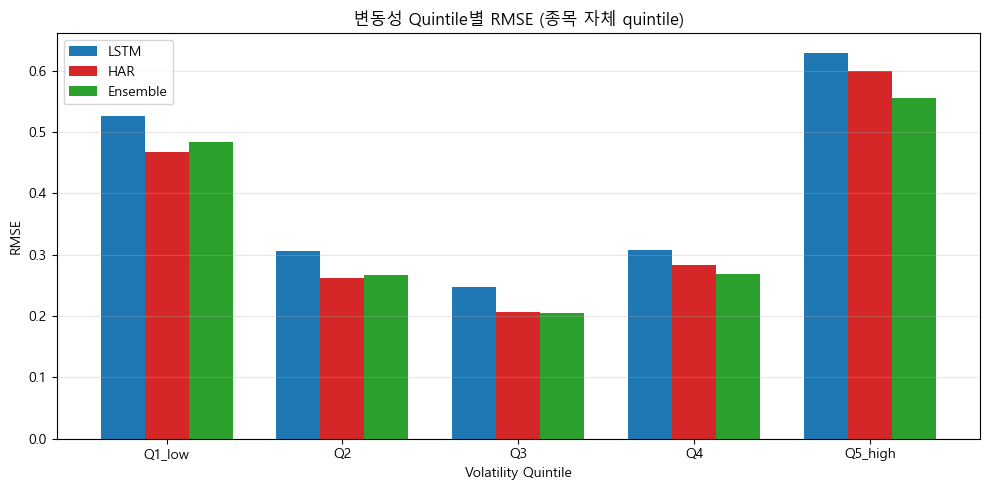

  💾 D_vol_regime_rmse.png
  💾 D_vol_regime_rmse.csv


In [36]:
# §2-D. 변동성 Regime별 예측력
print('=' * 75)
print('  §2-D. 변동성 Regime별 예측력 (종목 vol quintile)')
print('=' * 75)

# y_true 자체가 log RV 이므로 직접 quintile 분류
ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01'].copy()

# 종목별 y_true quintile (각 종목 자체 historical 분위)
def quintile_label(g):
    g = g.copy()
    g['vol_q'] = pd.qcut(g['y_true'], 5, labels=['Q1_low', 'Q2', 'Q3', 'Q4', 'Q5_high'],
                         duplicates='drop')
    return g

ens_oos = ens_oos.groupby('ticker', group_keys=False).apply(quintile_label)

# quintile별 RMSE
regime_rmse = ens_oos.groupby('vol_q', observed=True).agg(
    rmse_lstm=('sq_lstm', lambda x: np.sqrt(x.mean())),
    rmse_har=('sq_har', lambda x: np.sqrt(x.mean())),
    rmse_ens=('sq_ens', lambda x: np.sqrt(x.mean())),
    n=('y_true', 'count'),
)
print(f'  vol quintile별 RMSE:')
print(regime_rmse.round(4).to_string())

# 시각화 (bar)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
regime_rmse[['rmse_lstm', 'rmse_har', 'rmse_ens']].plot(kind='bar', ax=ax, width=0.75,
    color=['#1f77b4', '#d62728', '#2ca02c'])
ax.set_title('변동성 Quintile별 RMSE (종목 자체 quintile)')
ax.set_xlabel('Volatility Quintile')
ax.set_ylabel('RMSE')
ax.legend(['LSTM', 'HAR', 'Ensemble'])
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
out_path = OUT_DIR / 'D_vol_regime_rmse.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

regime_rmse.to_csv(OUT_DIR / 'D_vol_regime_rmse.csv')
print(f'  💾 D_vol_regime_rmse.csv')

### §2-E. VIX 분위별 예측 정확도 (시장 환경)

VIX tertile (low/mid/high, 33%/67%) 환경에서 LSTM vs HAR 우열.
VIX shock (high) 환경에서 LSTM 의 추가 정보 발현 여부 검정.

  §2-E. VIX 분위별 예측 정확도
  VIX tertile 기준: low<=14.68 <mid<= 19.18 <high
  VIX tier별 RMSE:
          rmse_lstm  rmse_har  rmse_ens       n
vix_tier                                       
Low        0.402500  0.385600  0.382000  708971
Mid        0.392500  0.379700  0.374000  727113
High       0.488100  0.410600  0.388500  717552

  LSTM 우위 (rmse_lstm < rmse_har) 환경:
    Low: LSTM-HAR diff = +0.0168 (HAR 우위)
    Mid: LSTM-HAR diff = +0.0128 (HAR 우위)
    High: LSTM-HAR diff = +0.0775 (HAR 우위)


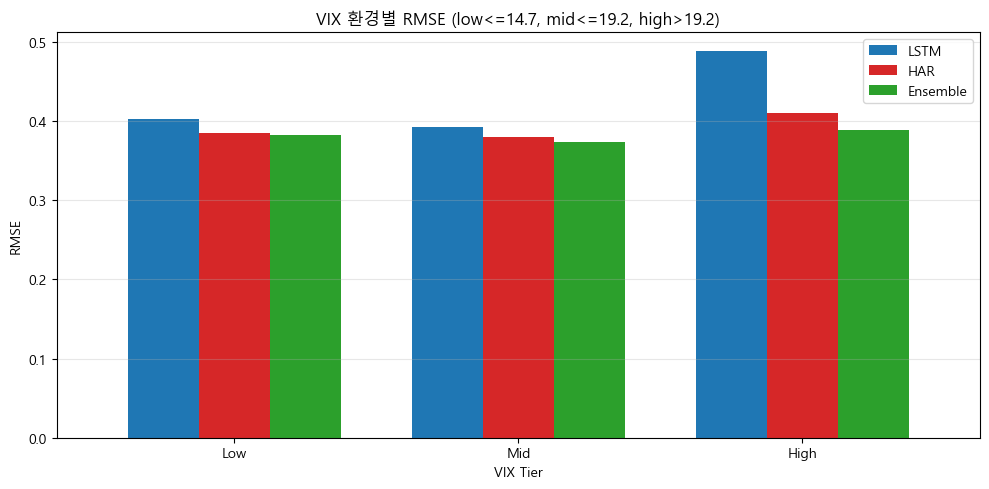

  💾 E_vix_tier_rmse.png
  💾 E_vix_tier_rmse.csv


In [37]:
# §2-E. VIX 분위별 예측 정확도
print('=' * 75)
print('  §2-E. VIX 분위별 예측 정확도')
print('=' * 75)

ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01'].copy()

# vix 일별 → date 별 매핑
vix_oos = vix.loc['2010-01-01':'2025-12-31']
vix_t1, vix_t2 = vix_oos.quantile([0.33, 0.67]).values
print(f'  VIX tertile 기준: low<={vix_t1:.2f} <mid<= {vix_t2:.2f} <high')

def vix_tier(d):
    v = vix_oos.get(d, np.nan)
    if pd.isna(v): return 'Unknown'
    if v <= vix_t1: return 'Low'
    elif v <= vix_t2: return 'Mid'
    else: return 'High'

ens_oos['vix_tier'] = ens_oos['date'].apply(vix_tier)
ens_oos = ens_oos[ens_oos['vix_tier'] != 'Unknown']

vix_rmse = ens_oos.groupby('vix_tier', observed=True).agg(
    rmse_lstm=('sq_lstm', lambda x: np.sqrt(x.mean())),
    rmse_har=('sq_har', lambda x: np.sqrt(x.mean())),
    rmse_ens=('sq_ens', lambda x: np.sqrt(x.mean())),
    n=('y_true', 'count'),
).reindex(['Low', 'Mid', 'High'])

print(f'  VIX tier별 RMSE:')
print(vix_rmse.round(4).to_string())

# LSTM 우위 비율 (LSTM RMSE < HAR RMSE)
print()
print('  LSTM 우위 (rmse_lstm < rmse_har) 환경:')
for tier in ['Low', 'Mid', 'High']:
    row = vix_rmse.loc[tier]
    diff = row['rmse_lstm'] - row['rmse_har']
    print(f'    {tier}: LSTM-HAR diff = {diff:+.4f} ({"LSTM 우위" if diff < 0 else "HAR 우위"})')

# 시각화 (bar)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
vix_rmse[['rmse_lstm', 'rmse_har', 'rmse_ens']].plot(kind='bar', ax=ax, width=0.75,
    color=['#1f77b4', '#d62728', '#2ca02c'])
ax.set_title(f'VIX 환경별 RMSE (low<={vix_t1:.1f}, mid<={vix_t2:.1f}, high>{vix_t2:.1f})')
ax.set_xlabel('VIX Tier')
ax.set_ylabel('RMSE')
ax.legend(['LSTM', 'HAR', 'Ensemble'])
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
out_path = OUT_DIR / 'E_vix_tier_rmse.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

vix_rmse.to_csv(OUT_DIR / 'E_vix_tier_rmse.csv')
print(f'  💾 E_vix_tier_rmse.csv')

### §2-F. Diebold-Mariano test (LSTM vs HAR, 종목별)

`DM stat = mean(loss_lstm - loss_har) / sqrt(HAC_var / n)`. h=21 (월간 평가).
종목별 어느 모델이 통계적으로 유의하게 우월한지 검정.

- DM < 0 + p < 0.05 → LSTM 통계적 우월
- DM > 0 + p < 0.05 → HAR 통계적 우월
- |DM| 작거나 p ≥ 0.05 → 차이 없음

  §2-F. Diebold-Mariano test (LSTM vs HAR, 종목별)
  전체 종목: 613 (clean: 613)
  결과 분포 (p<0.05 기준):
    LSTM 통계적 우월:  25 종목 (4.1%)
    HAR 통계적 우월:  144 종목 (23.5%)
    차이 없음:         444 종목 (72.4%)


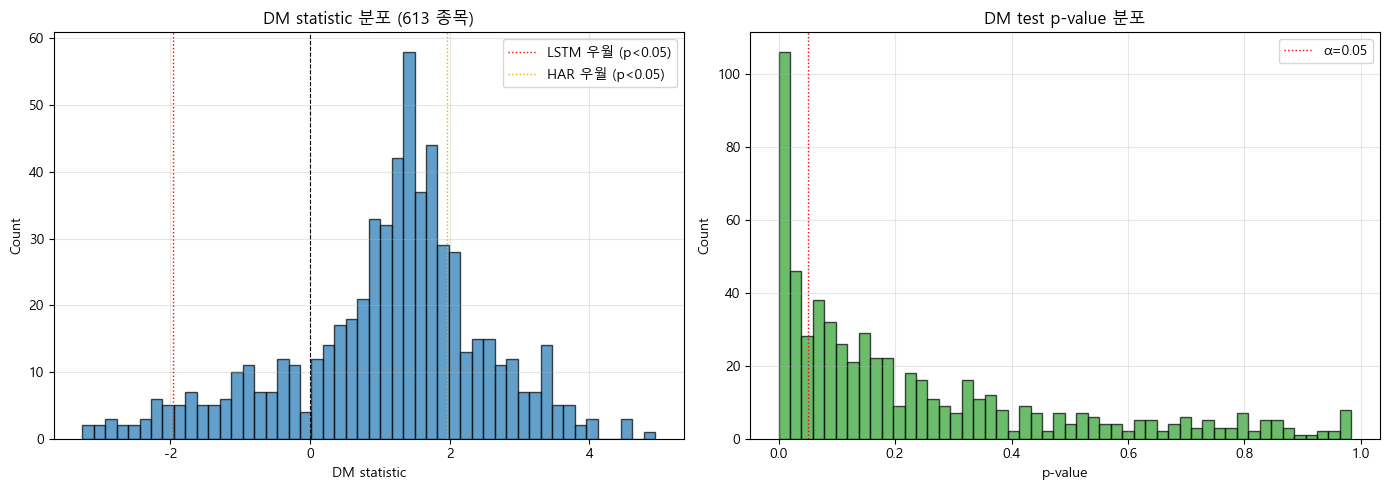

  💾 F_dm_test.png
  💾 F_dm_test.csv


In [38]:
# §2-F. Diebold-Mariano test
print('=' * 75)
print('  §2-F. Diebold-Mariano test (LSTM vs HAR, 종목별)')
print('=' * 75)

from scipy.stats import norm

def dm_test(loss_lstm, loss_har, h=21):
    """DM test (HAC variance, lag h-1).
    Returns (dm_stat, p_value, n).
    """
    d = loss_lstm - loss_har
    d = d[np.isfinite(d)]
    n = len(d)
    if n < 2 * h:
        return float('nan'), float('nan'), n
    d_mean = d.mean()
    gamma_0 = ((d - d_mean) ** 2).mean()
    s_var = gamma_0
    for k in range(1, h):
        if k >= n: break
        gamma_k = ((d[:-k] - d_mean) * (d[k:] - d_mean)).mean()
        s_var += 2 * (1 - k/h) * gamma_k
    if s_var <= 0:
        return float('nan'), float('nan'), n
    dm_stat = d_mean / np.sqrt(s_var / n)
    p = 2 * (1 - norm.cdf(abs(dm_stat)))
    return dm_stat, p, n

ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01']
dm_results = []
for ticker, g in ens_oos.groupby('ticker'):
    g = g.sort_values('date')
    dm, p, n = dm_test(g['sq_lstm'].values, g['sq_har'].values, h=21)
    dm_results.append({'ticker': ticker, 'dm_stat': dm, 'p_value': p, 'n': n})

dm_df = pd.DataFrame(dm_results)
dm_df_clean = dm_df.dropna()
print(f'  전체 종목: {len(dm_df)} (clean: {len(dm_df_clean)})')

# 통계 요약
n_lstm_sig = ((dm_df_clean['dm_stat'] < 0) & (dm_df_clean['p_value'] < 0.05)).sum()
n_har_sig = ((dm_df_clean['dm_stat'] > 0) & (dm_df_clean['p_value'] < 0.05)).sum()
n_neutral = ((dm_df_clean['p_value'] >= 0.05)).sum()

print(f'  결과 분포 (p<0.05 기준):')
print(f'    LSTM 통계적 우월: {n_lstm_sig:3d} 종목 ({n_lstm_sig/len(dm_df_clean)*100:.1f}%)')
print(f'    HAR 통계적 우월:  {n_har_sig:3d} 종목 ({n_har_sig/len(dm_df_clean)*100:.1f}%)')
print(f'    차이 없음:         {n_neutral:3d} 종목 ({n_neutral/len(dm_df_clean)*100:.1f}%)')

# 시각화 (DM stat 분포 + p-value 분포)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) DM stat 분포
axes[0].hist(dm_df_clean['dm_stat'], bins=50, alpha=0.7, color='#1f77b4', edgecolor='black')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(-1.96, color='red', linewidth=1, linestyle=':', label='LSTM 우월 (p<0.05)')
axes[0].axvline(1.96, color='orange', linewidth=1, linestyle=':', label='HAR 우월 (p<0.05)')
axes[0].set_xlabel('DM statistic')
axes[0].set_ylabel('Count')
axes[0].set_title(f'DM statistic 분포 ({len(dm_df_clean)} 종목)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (2) p-value 분포
axes[1].hist(dm_df_clean['p_value'], bins=50, alpha=0.7, color='#2ca02c', edgecolor='black')
axes[1].axvline(0.05, color='red', linewidth=1, linestyle=':', label='α=0.05')
axes[1].set_xlabel('p-value')
axes[1].set_ylabel('Count')
axes[1].set_title('DM test p-value 분포')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = OUT_DIR / 'F_dm_test.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

dm_df.to_csv(OUT_DIR / 'F_dm_test.csv', index=False)
print(f'  💾 F_dm_test.csv')

### §2-G. Sector × Best Model 교차표

각 종목별 최저 RMSE 모델 (LSTM/HAR/Ensemble) 결정 → sector × best model 분포.
(sector mapping 있을 때만 의미있는 결과, 없으면 model 분포만 출력)

  §2-G. Sector × Best Model 교차표
  Best model 분포:
    Ensemble  :  427 종목 (69.7%)
    HAR       :  167 종목 (27.2%)
    LSTM      :   19 종목 (3.1%)

  Sector × Best Model 교차표:
best_model              Ensemble  HAR  LSTM  total
sector                                            
Communication Services        12   11     0     23
Consumer Discretionary        40    6     2     48
Consumer Staples              22   12     0     34
Energy                         8   17     0     25
Financials                    66    8     2     76
Health Care                   37   20     2     59
Industrials                   62   11     4     77
Information Technology        56   12     1     69
Materials                     16    8     2     26
Real Estate                   25    5     1     31
Unknown                       72   36     5    113
Utilities                     11   21     0     32


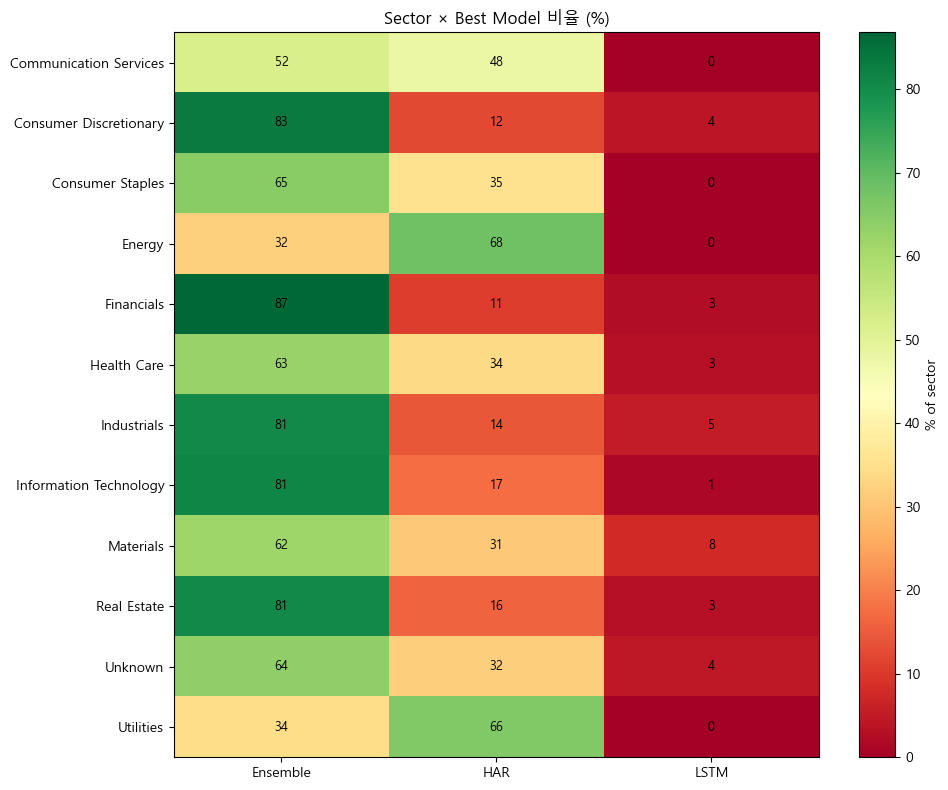

  💾 G_sector_best_model.png
  💾 G_best_per_ticker.csv


In [39]:
# §2-G. Sector × Best Model 교차표
print('=' * 75)
print('  §2-G. Sector × Best Model 교차표')
print('=' * 75)

ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01']
best_per_ticker = ens_oos.groupby('ticker').agg(
    rmse_lstm=('sq_lstm', lambda x: np.sqrt(x.mean())),
    rmse_har=('sq_har', lambda x: np.sqrt(x.mean())),
    rmse_ens=('sq_ens', lambda x: np.sqrt(x.mean())),
)

def best_model(row):
    rmses = {'LSTM': row['rmse_lstm'], 'HAR': row['rmse_har'], 'Ensemble': row['rmse_ens']}
    return min(rmses, key=rmses.get)

best_per_ticker['best_model'] = best_per_ticker.apply(best_model, axis=1)
print(f'  Best model 분포:')
best_cnt = best_per_ticker['best_model'].value_counts()
for m, n in best_cnt.items():
    print(f'    {m:10s}: {n:4d} 종목 ({n/len(best_per_ticker)*100:.1f}%)')

if SECTOR_AVAILABLE:
    best_per_ticker['sector'] = best_per_ticker.index.map(sector_map).fillna('Unknown')
    sect_best = pd.crosstab(best_per_ticker['sector'], best_per_ticker['best_model'])
    sect_best['total'] = sect_best.sum(axis=1)
    print()
    print(f'  Sector × Best Model 교차표:')
    print(sect_best.to_string())

    # Heatmap
    sect_best_pct = sect_best.drop(columns='total').div(sect_best['total'], axis=0) * 100
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    im = ax.imshow(sect_best_pct.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(sect_best_pct.columns)))
    ax.set_xticklabels(sect_best_pct.columns)
    ax.set_yticks(range(len(sect_best_pct.index)))
    ax.set_yticklabels(sect_best_pct.index)
    ax.set_title('Sector × Best Model 비율 (%)')
    # 값 표시
    for i in range(sect_best_pct.shape[0]):
        for j in range(sect_best_pct.shape[1]):
            ax.text(j, i, f'{sect_best_pct.values[i, j]:.0f}', ha='center', va='center', color='black', fontsize=9)
    plt.colorbar(im, ax=ax, label='% of sector')
    plt.tight_layout()
    out_path = OUT_DIR / 'G_sector_best_model.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'  💾 {out_path.name}')
    sect_best.to_csv(OUT_DIR / 'G_sector_best_model.csv')
else:
    print()
    print('  ⚠️ sector mapping 부재 → bar chart 만 출력')
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    best_cnt.plot(kind='bar', ax=ax, color=['#1f77b4', '#d62728', '#2ca02c'])
    ax.set_title('Best Model 분포 (전체 종목)')
    ax.set_ylabel('Count')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    out_path = OUT_DIR / 'G_best_model_dist.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'  💾 {out_path.name}')

best_per_ticker.to_csv(OUT_DIR / 'G_best_per_ticker.csv')
print(f'  💾 G_best_per_ticker.csv')

### §2-H. 종목별 Ensemble 가중치 안정성 (w_v4)

`w_v4 = LSTM 가중치` 의 시계열 변동 (rolling std). 어느 종목이 LSTM/HAR 가중치 swap 빈번한지.

  §2-H. 종목별 가중치 안정성 (w_v4 std)
  전체 종목: 613
  w_v4 평균 분포: mean=0.497, std=0.014
  w_v4 std 분포: mean=0.090, max=0.162

  Top 10 unstable (w_v4 std 큰):
        w_v4_mean  w_v4_std  w_v4_min  w_v4_max
ticker                                         
TIE      0.491000  0.162000  0.083000  0.892000
BMC      0.528000  0.131000  0.289000  0.811000
EP       0.471000  0.127000  0.096000  0.641000
FHN      0.480000  0.122000  0.120000  0.865000
SLG      0.461000  0.121000  0.057000  0.805000
PCG      0.455000  0.121000  0.061000  0.817000
GR       0.466000  0.120000  0.173000  0.788000
KG       0.469000  0.119000  0.121000  0.727000
SYF      0.528000  0.117000  0.206000  0.830000
REG      0.493000  0.117000  0.106000  0.862000

  Top 10 stable (w_v4 std 작은):
        w_v4_mean  w_v4_std  w_v4_min  w_v4_max
ticker                                         
MHS      0.510000  0.009000  0.500000  0.519000
BEAM     0.524000  0.025000  0.490000  0.578000
CARR     0.548000  0.034000  0.500000  0.600000
TE

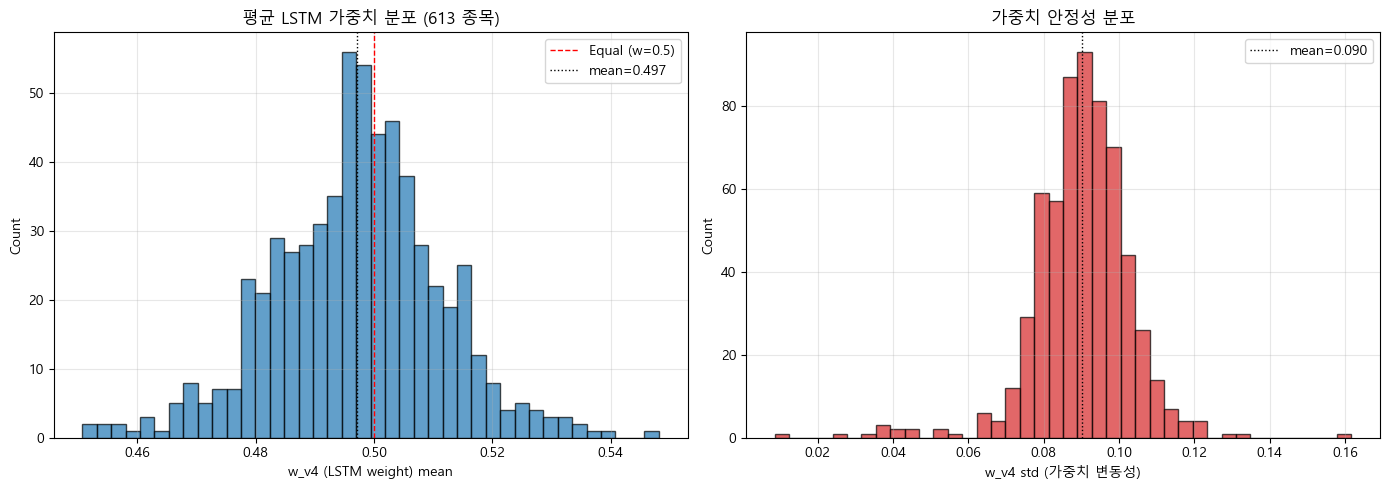

  💾 H_weight_stability.png
  💾 H_weight_stability.csv


In [40]:
# §2-H. 종목별 Ensemble 가중치 안정성
print('=' * 75)
print('  §2-H. 종목별 가중치 안정성 (w_v4 std)')
print('=' * 75)

ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01']
w_stats = ens_oos.groupby('ticker').agg(
    w_v4_mean=('w_v4', 'mean'),
    w_v4_std=('w_v4', 'std'),
    w_v4_min=('w_v4', 'min'),
    w_v4_max=('w_v4', 'max'),
)
print(f'  전체 종목: {len(w_stats)}')
print(f'  w_v4 평균 분포: mean={w_stats["w_v4_mean"].mean():.3f}, std={w_stats["w_v4_mean"].std():.3f}')
print(f'  w_v4 std 분포: mean={w_stats["w_v4_std"].mean():.3f}, max={w_stats["w_v4_std"].max():.3f}')

print()
print('  Top 10 unstable (w_v4 std 큰):')
top10_unstable = w_stats.nlargest(10, 'w_v4_std')
print(top10_unstable.round(3).to_string())
print()
print('  Top 10 stable (w_v4 std 작은):')
bot10_stable = w_stats.nsmallest(10, 'w_v4_std')
print(bot10_stable.round(3).to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) w_v4 mean 분포
axes[0].hist(w_stats['w_v4_mean'], bins=40, alpha=0.7, color='#1f77b4', edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1, label='Equal (w=0.5)')
axes[0].axvline(w_stats['w_v4_mean'].mean(), color='black', linestyle=':',
                linewidth=1, label=f'mean={w_stats["w_v4_mean"].mean():.3f}')
axes[0].set_xlabel('w_v4 (LSTM weight) mean')
axes[0].set_ylabel('Count')
axes[0].set_title(f'평균 LSTM 가중치 분포 ({len(w_stats)} 종목)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (2) w_v4 std 분포
axes[1].hist(w_stats['w_v4_std'], bins=40, alpha=0.7, color='#d62728', edgecolor='black')
axes[1].axvline(w_stats['w_v4_std'].mean(), color='black', linestyle=':',
                linewidth=1, label=f'mean={w_stats["w_v4_std"].mean():.3f}')
axes[1].set_xlabel('w_v4 std (가중치 변동성)')
axes[1].set_ylabel('Count')
axes[1].set_title('가중치 안정성 분포')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = OUT_DIR / 'H_weight_stability.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

w_stats.to_csv(OUT_DIR / 'H_weight_stability.csv')
print(f'  💾 H_weight_stability.csv')

### §2-I. 시기별 예측 vs 실제 산점도 (5 시기 subplot grid)

5 시기 × {Ensemble pred vs y_true} subplot. diagonal 참고선 + correlation.
시기별로 모델 calibration 변화 추이.

  §2-I. 시기별 Pred vs True 산점도 (5 시기)


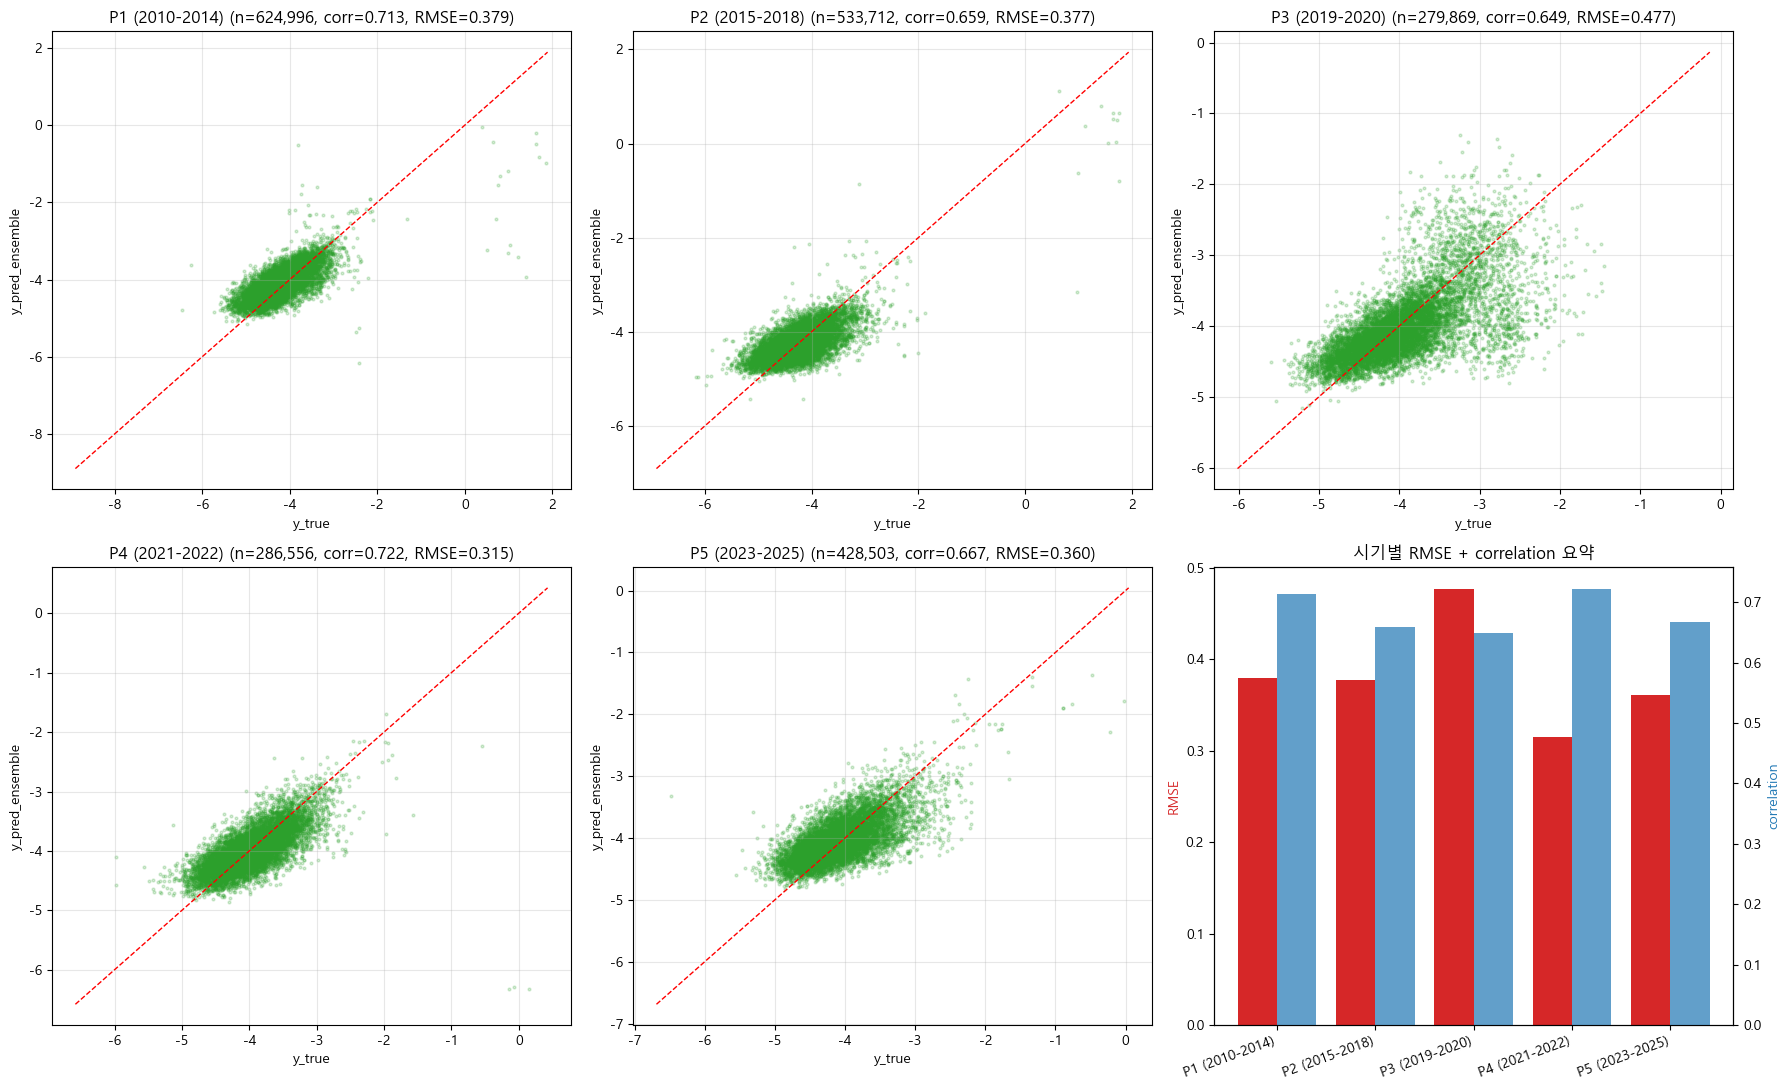

  💾 I_period_scatter.png

  시기별 통계:
        period      n     corr     rmse  y_true_mean  y_pred_mean
P1 (2010-2014) 624996 0.713000 0.379000    -4.228000    -4.104000
P2 (2015-2018) 533712 0.659000 0.377000    -4.256000    -4.251000
P3 (2019-2020) 279869 0.649000 0.477000    -3.960000    -4.016000
P4 (2021-2022) 286556 0.722000 0.315000    -3.971000    -3.978000
P5 (2023-2025) 428503 0.667000 0.360000    -4.077000    -4.032000
  💾 I_period_stats.csv


In [41]:
# §2-I. 시기별 예측 vs 실제 산점도
print('=' * 75)
print('  §2-I. 시기별 Pred vs True 산점도 (5 시기)')
print('=' * 75)

ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01']

# 시기별 통계 + 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

period_stats = []
for i, period in enumerate(PERIOD_ORDER):
    sub = ens_oos[ens_oos['period'] == period]
    if len(sub) == 0:
        axes[i].set_title(f'{period} (no data)')
        continue
    # 샘플링 (10000개) for 시각화 속도
    sub_sample = sub.sample(n=min(10000, len(sub)), random_state=42)
    ax = axes[i]
    ax.scatter(sub_sample['y_true'], sub_sample['y_pred_ensemble'],
               alpha=0.2, s=4, color='#2ca02c')
    ax.plot([sub['y_true'].min(), sub['y_true'].max()],
            [sub['y_true'].min(), sub['y_true'].max()],
            color='red', linestyle='--', linewidth=1)
    corr = sub[['y_true', 'y_pred_ensemble']].corr().iloc[0, 1]
    rmse = np.sqrt(sub['sq_ens'].mean())
    ax.set_title(f'{period} (n={len(sub):,}, corr={corr:.3f}, RMSE={rmse:.3f})')
    ax.set_xlabel('y_true')
    ax.set_ylabel('y_pred_ensemble')
    ax.grid(True, alpha=0.3)
    period_stats.append({
        'period': period, 'n': len(sub), 'corr': corr, 'rmse': rmse,
        'y_true_mean': sub['y_true'].mean(),
        'y_pred_mean': sub['y_pred_ensemble'].mean(),
    })

# 6번째 axis: 시기별 RMSE / corr summary
ax = axes[5]
ps_df = pd.DataFrame(period_stats)
x = np.arange(len(ps_df))
ax.bar(x - 0.2, ps_df['rmse'], width=0.4, color='#d62728', label='RMSE')
ax2 = ax.twinx()
ax2.bar(x + 0.2, ps_df['corr'], width=0.4, color='#1f77b4', label='corr', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(ps_df['period'], rotation=20, ha='right')
ax.set_ylabel('RMSE', color='#d62728')
ax2.set_ylabel('correlation', color='#1f77b4')
ax.set_title('시기별 RMSE + correlation 요약')

plt.tight_layout()
out_path = OUT_DIR / 'I_period_scatter.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

print()
print('  시기별 통계:')
print(ps_df.round(3).to_string(index=False))
ps_df.to_csv(OUT_DIR / 'I_period_stats.csv', index=False)
print(f'  💾 I_period_stats.csv')

### §2-J. Top/Bottom 5 종목 case study (5 시기 cover 종목만)

RMSE 기준 best 5 + worst 5 종목의 y_true / y_pred timeline.

⭐ **공정성 보강**: §2-B 와 동일 — 5 시기 모두 cover 한 종목만 비교.
인수/파산/신규 종목의 단편 학습 RMSE 가 비교 결과 왜곡 방지.

  §2-J. Top/Bottom 5 종목 case study (5 시기 cover 종목만)
  전체 종목: 613, 5 시기 cover: 503
  Best 5 (RMSE 작은): ['STLD', 'LEN', 'PEG', 'MU', 'NUE']
  Worst 5 (RMSE 큰):  ['CVG', 'PBI', 'FOSL', 'KG', 'DXC']


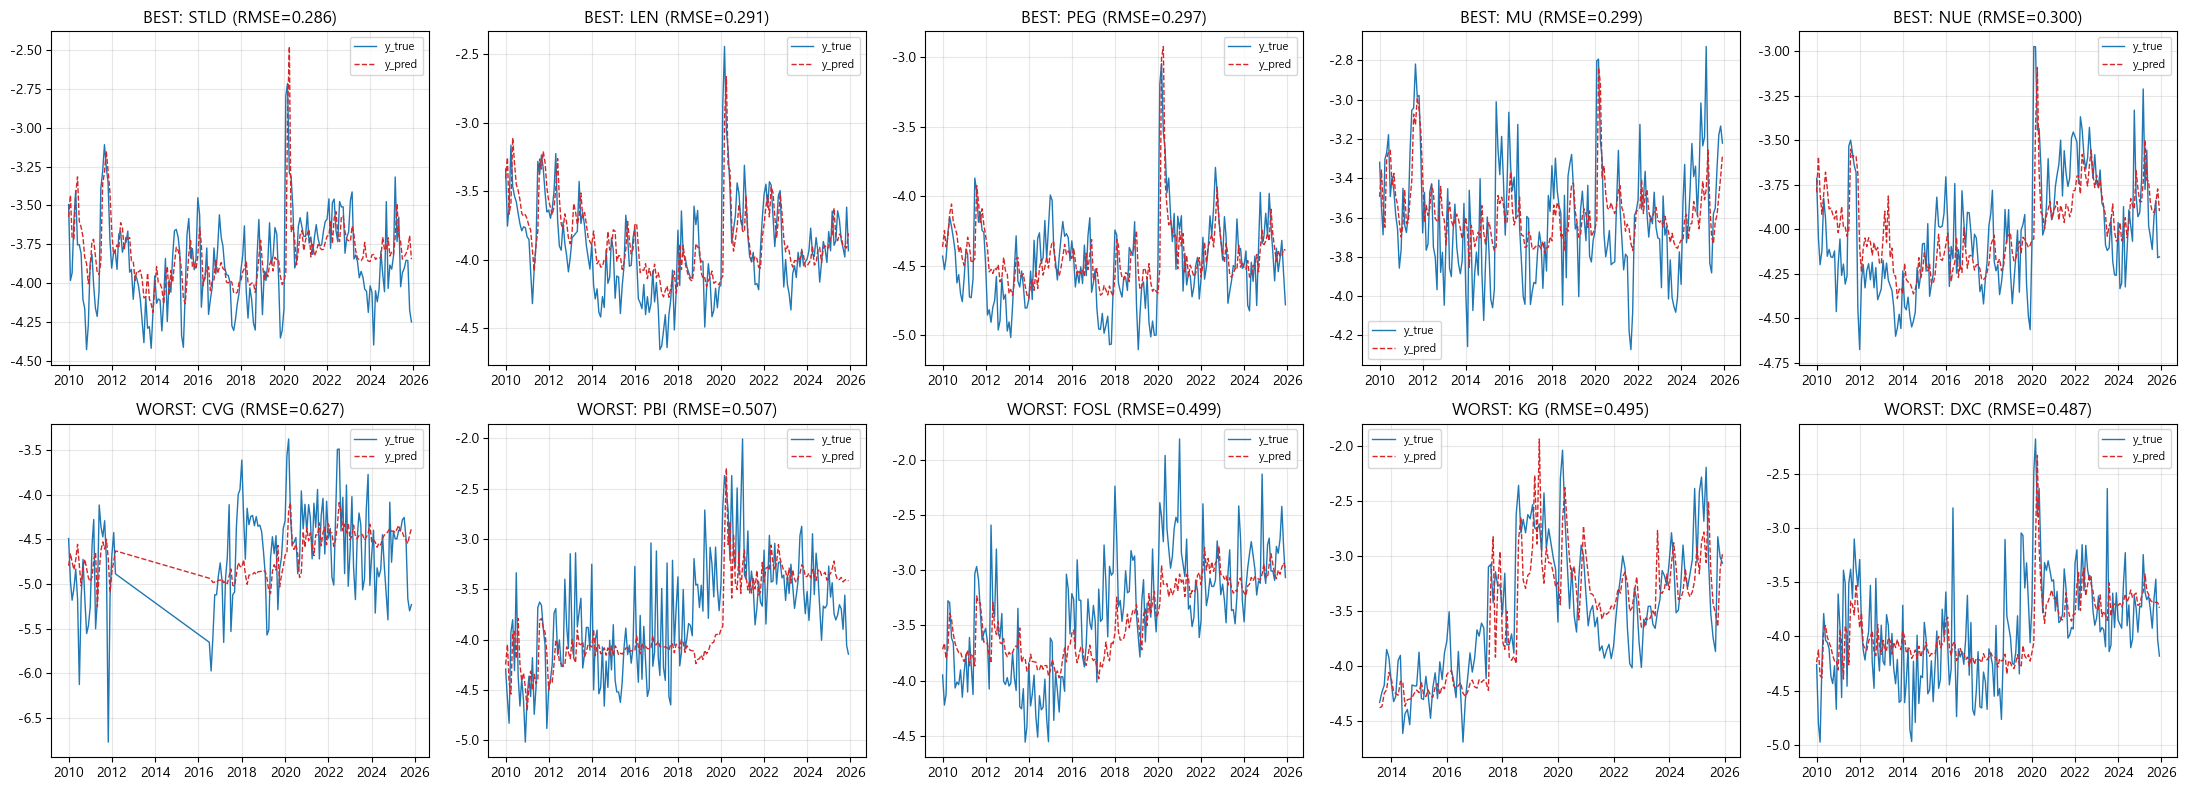

  💾 J_top_bottom_case_study.png
  💾 J_case_study.csv


In [42]:
# §2-J. Top/Bottom 10 종목 case study
print('=' * 75)
print('  §2-J. Top/Bottom 5 종목 case study (5 시기 cover 종목만)')
print('=' * 75)

ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01']

# 5 시기 cover 종목 식별 (§2-B 와 동일 로직)
period_count = ens_oos.groupby('ticker')['period'].nunique()
full_period_tickers = period_count[period_count == 5].index.tolist()
print(f'  전체 종목: {len(period_count)}, 5 시기 cover: {len(full_period_tickers)}')

# ⭐ 5 시기 cover 종목 중에서 best/worst 선정
ens_full = ens_oos[ens_oos['ticker'].isin(full_period_tickers)]
ticker_rmse = ens_full.groupby('ticker').apply(
    lambda g: np.sqrt(g['sq_ens'].mean())
).rename('rmse_ens')

best5 = ticker_rmse.nsmallest(5).index.tolist()
worst5 = ticker_rmse.nlargest(5).index.tolist()
print(f'  Best 5 (RMSE 작은): {best5}')
print(f'  Worst 5 (RMSE 큰):  {worst5}')

# 시각화 (best 5 + worst 5 = 10 panel)
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for i, ticker in enumerate(best5):
    ax = axes[0, i]
    sub = ens_oos[ens_oos['ticker'] == ticker].sort_values('date')
    # 월별 평균
    mt = sub.groupby(sub['date'].dt.to_period('M')).agg(
        y_true=('y_true', 'mean'),
        y_pred=('y_pred_ensemble', 'mean'),
    )
    mt.index = mt.index.to_timestamp()
    ax.plot(mt.index, mt['y_true'], label='y_true', color='#1f77b4', linewidth=1)
    ax.plot(mt.index, mt['y_pred'], label='y_pred', color='#d62728', linewidth=1, linestyle='--')
    rmse = ticker_rmse[ticker]
    ax.set_title(f'BEST: {ticker} (RMSE={rmse:.3f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for i, ticker in enumerate(worst5):
    ax = axes[1, i]
    sub = ens_oos[ens_oos['ticker'] == ticker].sort_values('date')
    mt = sub.groupby(sub['date'].dt.to_period('M')).agg(
        y_true=('y_true', 'mean'),
        y_pred=('y_pred_ensemble', 'mean'),
    )
    mt.index = mt.index.to_timestamp()
    ax.plot(mt.index, mt['y_true'], label='y_true', color='#1f77b4', linewidth=1)
    ax.plot(mt.index, mt['y_pred'], label='y_pred', color='#d62728', linewidth=1, linestyle='--')
    rmse = ticker_rmse[ticker]
    ax.set_title(f'WORST: {ticker} (RMSE={rmse:.3f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = OUT_DIR / 'J_top_bottom_case_study.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

# 표 저장
case_df = pd.DataFrame({
    'rank': list(range(1, 6)) + list(range(1, 6)),
    'category': ['best'] * 5 + ['worst'] * 5,
    'ticker': best5 + worst5,
    'rmse_ens': [ticker_rmse[t] for t in best5 + worst5],
})
case_df.to_csv(OUT_DIR / 'J_case_study.csv', index=False)
print(f'  💾 J_case_study.csv')

### §2-K. CV fold별 성능 (k=0~223 RMSE 추이)

walk-forward CV 의 fold (k=0~223) 별 RMSE 평균 시계열. fold drift / 학습 안정성 검정.

  §2-K. CV fold별 RMSE 추이 (k=0~223)
  fold 수: 224
  fold RMSE (Ensemble) 통계: mean=0.3789, std=0.0953, min=0.2514, max=1.0741

  최우 5 fold (RMSE 작은):
 fold  rmse_ens   date_min   date_max     n
  183  0.251430 2022-07-27 2025-12-01  9780
  187  0.255991 2022-11-23 2025-12-01  9736
  181  0.261441 2022-05-25 2025-12-01  9791
  172  0.263748 2021-08-25 2025-12-01 10053
  188  0.281531 2022-12-23 2025-12-01  9709

  최열 5 fold (RMSE 큰):
 fold  rmse_ens   date_min   date_max     n
  153  1.074116 2020-01-27 2025-12-01 10402
  154  0.969062 2020-02-26 2025-12-01 10373
   16  0.727198 2008-08-20 2025-12-01 12532
   23  0.699122 2009-03-23 2025-05-12 12427
  155  0.692823 2020-03-26 2025-11-19 10365


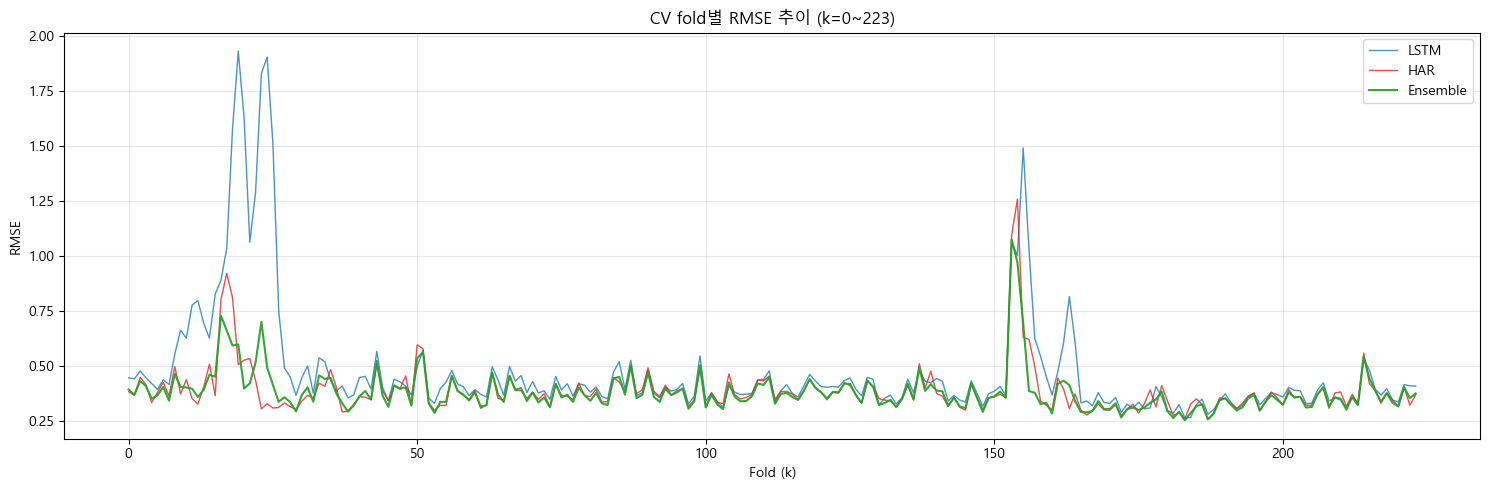

  💾 K_fold_rmse.png
  💾 K_fold_rmse.csv


In [43]:
# §2-K. CV fold별 성능
print('=' * 75)
print('  §2-K. CV fold별 RMSE 추이 (k=0~223)')
print('=' * 75)

fold_stats = ens_sw.groupby('fold').agg(
    rmse_lstm=('sq_lstm', lambda x: np.sqrt(x.mean())),
    rmse_har=('sq_har', lambda x: np.sqrt(x.mean())),
    rmse_ens=('sq_ens', lambda x: np.sqrt(x.mean())),
    n=('y_true', 'count'),
    date_min=('date', 'min'),
    date_max=('date', 'max'),
).reset_index()

print(f'  fold 수: {len(fold_stats)}')
print(f'  fold RMSE (Ensemble) 통계: mean={fold_stats["rmse_ens"].mean():.4f}, '
      f'std={fold_stats["rmse_ens"].std():.4f}, '
      f'min={fold_stats["rmse_ens"].min():.4f}, max={fold_stats["rmse_ens"].max():.4f}')
print()
print(f'  최우 5 fold (RMSE 작은):')
print(fold_stats.nsmallest(5, 'rmse_ens')[['fold', 'rmse_ens', 'date_min', 'date_max', 'n']].to_string(index=False))
print()
print(f'  최열 5 fold (RMSE 큰):')
print(fold_stats.nlargest(5, 'rmse_ens')[['fold', 'rmse_ens', 'date_min', 'date_max', 'n']].to_string(index=False))

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(fold_stats['fold'], fold_stats['rmse_lstm'], label='LSTM', color='#1f77b4', linewidth=1, alpha=0.8)
ax.plot(fold_stats['fold'], fold_stats['rmse_har'], label='HAR', color='#d62728', linewidth=1, alpha=0.8)
ax.plot(fold_stats['fold'], fold_stats['rmse_ens'], label='Ensemble', color='#2ca02c', linewidth=1.5, alpha=0.95)
ax.set_xlabel('Fold (k)')
ax.set_ylabel('RMSE')
ax.set_title(f'CV fold별 RMSE 추이 (k=0~{fold_stats["fold"].max()})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = OUT_DIR / 'K_fold_rmse.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

fold_stats.to_csv(OUT_DIR / 'K_fold_rmse.csv', index=False)
print(f'  💾 K_fold_rmse.csv')

### §2-L. y_true vs y_pred 분포 비교 (calibration 진단)

KDE / QQ plot / percentile 비교 → 모델이 y 분포를 calibration 잘 했는지.

  §2-L. y_true vs y_pred 분포 비교
  Percentile 비교:
 percentile    y_true  y_pred_lstm  y_pred_har  y_pred_ensemble
          1 -5.160000    -4.771000   -4.855000        -4.796000
          5 -4.889000    -4.627000   -4.684000        -4.647000
         25 -4.489000    -4.341000   -4.397000        -4.367000
         50 -4.177000    -4.112000   -4.172000        -4.143000
         75 -3.836000    -3.840000   -3.914000        -3.882000
         95 -3.250000    -3.344000   -3.491000        -3.428000
         99 -2.698000    -2.363000   -3.125000        -2.895000

  y_true mean: -4.1359, std: 0.5222
  y_pred_ens mean: -4.0979, std: 0.3963


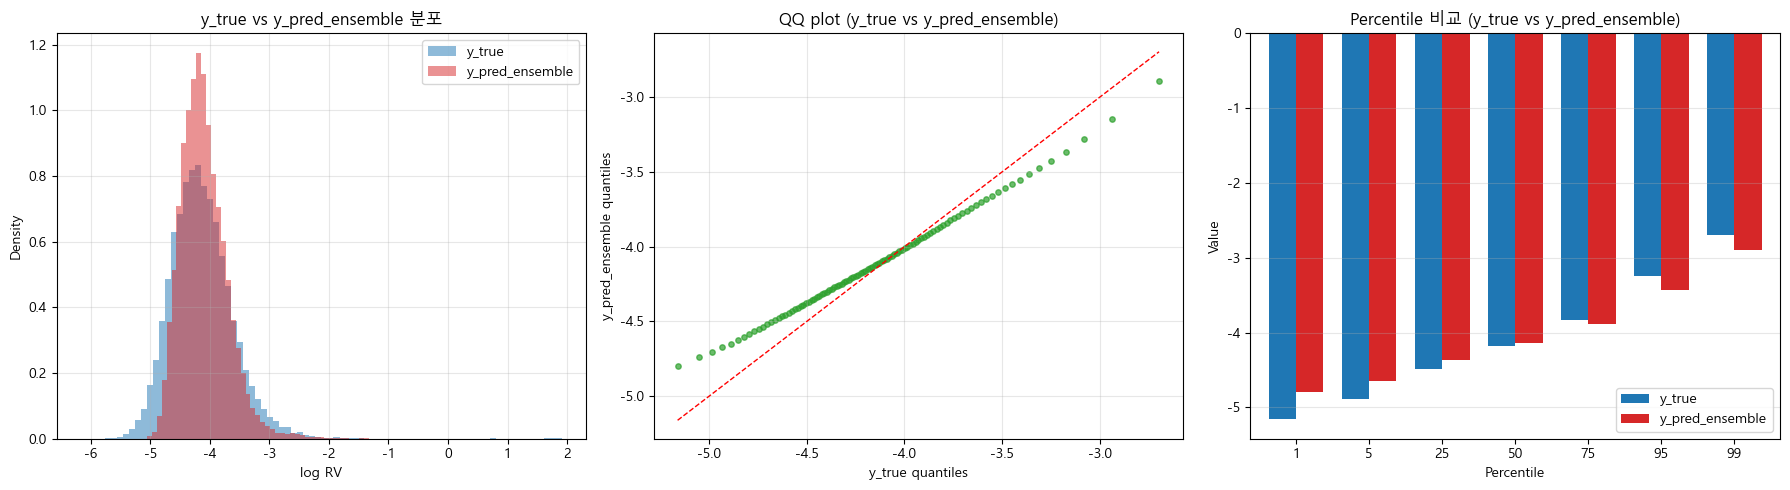

  💾 L_distribution.png
  💾 L_percentile_table.csv


In [44]:
# §2-L. y_true vs y_pred 분포 비교
print('=' * 75)
print('  §2-L. y_true vs y_pred 분포 비교')
print('=' * 75)

ens_oos = ens_sw[ens_sw['date'] >= '2010-01-01']

# percentile table
pcts = [1, 5, 25, 50, 75, 95, 99]
pct_table = pd.DataFrame({
    'percentile': pcts,
    'y_true': [np.percentile(ens_oos['y_true'], p) for p in pcts],
    'y_pred_lstm': [np.percentile(ens_oos['y_pred_lstm'], p) for p in pcts],
    'y_pred_har': [np.percentile(ens_oos['y_pred_har'], p) for p in pcts],
    'y_pred_ensemble': [np.percentile(ens_oos['y_pred_ensemble'], p) for p in pcts],
})
print('  Percentile 비교:')
print(pct_table.round(3).to_string(index=False))
print()
print(f'  y_true mean: {ens_oos["y_true"].mean():.4f}, std: {ens_oos["y_true"].std():.4f}')
print(f'  y_pred_ens mean: {ens_oos["y_pred_ensemble"].mean():.4f}, std: {ens_oos["y_pred_ensemble"].std():.4f}')

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) KDE (random sample 50000개)
sample = ens_oos.sample(n=min(50000, len(ens_oos)), random_state=42)
axes[0].hist(sample['y_true'], bins=80, alpha=0.5, color='#1f77b4', label='y_true', density=True)
axes[0].hist(sample['y_pred_ensemble'], bins=80, alpha=0.5, color='#d62728',
             label='y_pred_ensemble', density=True)
axes[0].set_xlabel('log RV')
axes[0].set_ylabel('Density')
axes[0].set_title('y_true vs y_pred_ensemble 분포')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (2) QQ plot
qs = np.linspace(0.01, 0.99, 99)
q_true = np.quantile(ens_oos['y_true'], qs)
q_pred = np.quantile(ens_oos['y_pred_ensemble'], qs)
axes[1].scatter(q_true, q_pred, s=15, alpha=0.7, color='#2ca02c')
axes[1].plot([q_true.min(), q_true.max()], [q_true.min(), q_true.max()],
             color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('y_true quantiles')
axes[1].set_ylabel('y_pred_ensemble quantiles')
axes[1].set_title('QQ plot (y_true vs y_pred_ensemble)')
axes[1].grid(True, alpha=0.3)

# (3) percentile bar
pct_plot = pct_table.set_index('percentile')[['y_true', 'y_pred_ensemble']]
pct_plot.plot(kind='bar', ax=axes[2], width=0.75, color=['#1f77b4', '#d62728'])
axes[2].set_xlabel('Percentile')
axes[2].set_ylabel('Value')
axes[2].set_title('Percentile 비교 (y_true vs y_pred_ensemble)')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
out_path = OUT_DIR / 'L_distribution.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  💾 {out_path.name}')

pct_table.to_csv(OUT_DIR / 'L_percentile_table.csv', index=False)
print(f'  💾 L_percentile_table.csv')

## §3. 종합 요약 (12 분석 결과 압축)

In [45]:
# §3. 종합 요약
print('=' * 75)
print('  §3. 12 분석 종합 요약')
print('=' * 75)

ens_oos_all = ens_sw[ens_sw['date'] >= '2010-01-01']
overall_rmse = {
    'rmse_lstm_overall': float(np.sqrt(ens_oos_all['sq_lstm'].mean())),
    'rmse_har_overall': float(np.sqrt(ens_oos_all['sq_har'].mean())),
    'rmse_ensemble_overall': float(np.sqrt(ens_oos_all['sq_ens'].mean())),
    'bias_ensemble_overall': float(ens_oos_all['err_ens'].mean()),
    'n_predictions': int(len(ens_oos_all)),
    'n_tickers': int(ens_oos_all['ticker'].nunique()),
    'n_folds': int(ens_oos_all['fold'].nunique()),
    'n_lstm_sig_dm': int(((dm_df_clean['dm_stat'] < 0) & (dm_df_clean['p_value'] < 0.05)).sum()),
    'n_har_sig_dm': int(((dm_df_clean['dm_stat'] > 0) & (dm_df_clean['p_value'] < 0.05)).sum()),
    'n_neutral_dm': int((dm_df_clean['p_value'] >= 0.05).sum()),
}
print(f'  전체 OOS (2010-2025) RMSE:')
print(f'    LSTM:     {overall_rmse["rmse_lstm_overall"]:.4f}')
print(f'    HAR:      {overall_rmse["rmse_har_overall"]:.4f}')
print(f'    Ensemble: {overall_rmse["rmse_ensemble_overall"]:.4f}')
print(f'  전체 bias (Ensemble): {overall_rmse["bias_ensemble_overall"]:+.4f}')
print()
print(f'  DM-test (LSTM vs HAR):')
print(f'    LSTM 통계적 우월:  {overall_rmse["n_lstm_sig_dm"]:3d} 종목 ({overall_rmse["n_lstm_sig_dm"]/len(dm_df_clean)*100:.1f}%)')
print(f'    HAR 통계적 우월:   {overall_rmse["n_har_sig_dm"]:3d} 종목 ({overall_rmse["n_har_sig_dm"]/len(dm_df_clean)*100:.1f}%)')
print(f'    차이 없음:          {overall_rmse["n_neutral_dm"]:3d} 종목 ({overall_rmse["n_neutral_dm"]/len(dm_df_clean)*100:.1f}%)')
print()
print(f'  Best Model 분포:')
for m, n in best_per_ticker['best_model'].value_counts().items():
    print(f'    {m:10s}: {n:3d} 종목 ({n/len(best_per_ticker)*100:.1f}%)')

# JSON 저장 (05c 종합 비교 활용)
summary = {
    'notebook': '05a_v2_lstm.ipynb',
    'overall': overall_rmse,
    'period_stats': {p['period']: {k: float(v) for k, v in p.items() if k != 'period'} for p in period_stats},
}
out_json = OUT_DIR / 'summary.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'\n💾 {out_json.name}')
print(f'   (05c 종합 비교 노트북 활용)')

print()
print('=' * 75)
print('  ✅ 12 분석 완료. outputs/05a_v2_lstm_diag/ 에 17 개 산출물 저장.')
print('=' * 75)

  §3. 12 분석 종합 요약
  전체 OOS (2010-2025) RMSE:
    LSTM:     0.4298
    HAR:      0.3922
    Ensemble: 0.3815
  전체 bias (Ensemble): +0.0380

  DM-test (LSTM vs HAR):
    LSTM 통계적 우월:   25 종목 (4.1%)
    HAR 통계적 우월:   144 종목 (23.5%)
    차이 없음:          444 종목 (72.4%)

  Best Model 분포:
    Ensemble  : 427 종목 (69.7%)
    HAR       : 167 종목 (27.2%)
    LSTM      :  19 종목 (3.1%)

💾 summary.json
   (05c 종합 비교 노트북 활용)

  ✅ 12 분석 완료. outputs/05a_v2_lstm_diag/ 에 17 개 산출물 저장.
